## Generate Sine Wave

In [70]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt

In [127]:
samplerate = 1000  # 1000 points every second
# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq = 5
sineWave = 1.2*np.sin(2*np.pi*freq*timeAxis)

## Quantization is discretization in time

### Quantizatiopn steps and bits relationship

In [144]:
steps = 8
# Take log to the base 2
bits = int(np.log2(steps))

print("For Quantization in",steps, "steps, we require:",bits,"bits")

For Quantization in 8 steps, we require: 3 bits


Quantize the sinewave using np.clip: https://numpy.org/doc/2.1/reference/generated/numpy.clip.html

In [145]:
# Normalize the input Signal 
sineWave = sineWave/max(sineWave)
# Calculate the number of Quantization steps 
levels = 2 ** (bits - 1)
    
# Calculate step size
stepSize = 1 / levels

# Clip the signal between -1 and (1-step_size)
sineClipped = np.clip(sineWave, -1, 1-step_size)

# Quantize by multiplying and rounding then dividing
# The division scales our rounded integers back to the original signal range.
quantizedSine = np.round(sineWave * levels) / levels

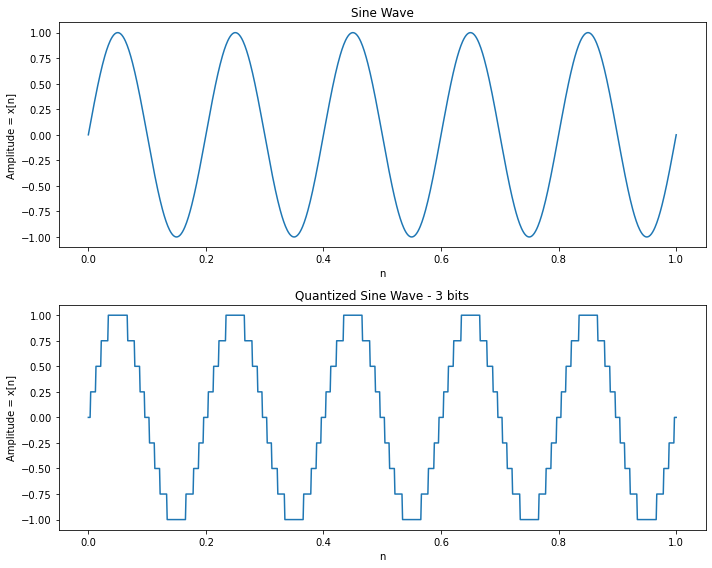

In [146]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8))  # 2 rows, 1 column

# Plot each sine wave in its respective subplot
axes[0].plot(timeAxis,sineWave)
axes[0].set_title("Sine Wave")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude = x[n]")

axes[1].plot(timeAxis,quantizedSine)
axes[1].set_title("Quantized Sine Wave - 3 bits")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Amplitude = x[n]")

plt.tight_layout()
plt.show()


### Quantization Error

$$ e_q[n] = x_q[n] - x[n] $$

In [147]:
# Generate Sine Wave

samplerate = 1000  # 1000 points every second
# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq = 5
sineWave = 1.2*np.sin(2*np.pi*freq*timeAxis)

In [148]:
# Quantize Sine Wave to 8 levels

# Normalize the input Signal 
sineWave = sineWave/max(sineWave)
bits = 3
# Calculate the number of Quantization steps 
levels = 2 ** (bits - 1)
    
# Calculate step size
stepSize = 1 / levels

# Clip the signal between -1 and (1-step_size)
sineClipped = np.clip(sineWave, -1, 1-step_size)

# Quantize by multiplying and rounding then dividing
# The division scales our rounded integers back to the original signal range.
quantizedSine = np.round(sineWave * levels) / levels


# Same operation written as a function:
def quantize_signal(x, bits):
    mult = 2**(bits - 1)
    stepSize = 1/mult
    xClip = np.clip(x, -1, 1-stepSize)
    return np.round(xClip * mult)/mult

In [149]:
Quanterror = quantizedSine - sineWave

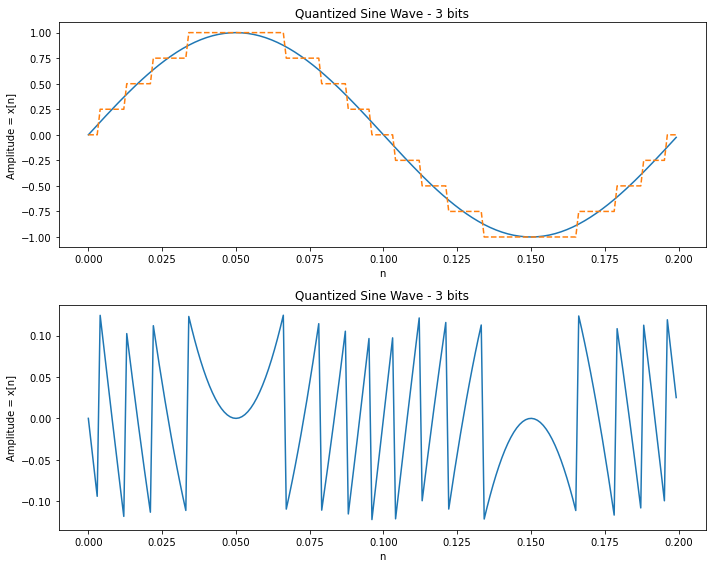

In [153]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8))  # 2 rows, 1 column

# Plot each sine wave in its respective subplot
axes[0].plot(timeAxis[0:200],sineWave[0:200])
axes[0].set_title("Sine Wave & Quantized Sine Wave")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude = x[n]")

axes[0].plot(timeAxis[0:200],quantizedSine[0:200], '--')
axes[0].set_title("Quantized Sine Wave - 3 bits")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude = x[n]")

axes[1].plot(timeAxis[0:200],Quanterror[0:200])
axes[1].set_title("Quantized Sine Wave - 3 bits")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Amplitude = x[n]")

plt.tight_layout()
plt.show()

### Activity

Try Quantizing audiorate sinusoids at various bit depths (2,4,8,12,24). Store the waveform and listen to the generated signal.

Bonus: Visualize the magnitude spectrum

## SNR (Signal To Noise Ratio)


$$ SNR' = \frac{signal\_energy}{noise\_energy} = \frac{W_s}{W_{qe}} $$

where,

The power/energy (W) can be calculated as the mean square value over time:
$$ W = \frac{1}{T}\int_0^T x^2(t)dt $$
For discrete signals, this becomes:
$$ W = \frac{1}{N}\sum_{n=0}^{N-1} x^2[n] $$

Theoretically, We have shown that the power of quantization error is, when assuming a uniform probability density for quantization error.

$$W_{qe} = \frac{\Delta^2}{12}$$, where $\Delta$ is the quantization stepsize. 

So our theoretical SNR equation becomes:
$$ SNR' = \frac{W_s}{W_{qe}} = \frac{\frac{1}{N}\sum_{n=0}^{N-1} x^2[n]}{\frac{\Delta^2}{12}} $$


we often depict it using Decibel (dB).
$$ SNR_{dB} = 10\log_{10}(\frac{W_s}{W_{qe}}) $$

Decibel (dB) is a way to express ratios on a logarithmic scale. The scale compresses wide ranges into manageable numbers and match how humans perceive many natural phenomena.

Additionally (pun intended), multiplication operations turn into additon in the logarithmic scale!


### SNR can be improved by
 - Reducing the noise power
 - Increasing the power of the clean signal

In [161]:
def theoretical_snr(bits):
    
    # For a sine wave, signal power is 1/2
    signal_power = 0.5
    # Quantization error power is Δ²/12
    delta = 2 / (2**bits)  # Step size
    error_power = delta**2 / 12
    
    snr = signal_power / error_power
    decibelsnr = 10 * np.log10(snr)
    return decibelsnr

In [162]:
def calculate_snr(signal, quantized):
    # Calculate quantization error
    error = quantized - signal
    
    # Calculate powers
    signal_power = np.mean(signal**2)
    error_power = np.mean(error**2)
    
    # Calculate SNR
    snr = signal_power / error_power
    snr_db = 10 * np.log10(snr)
    
    return snr_db

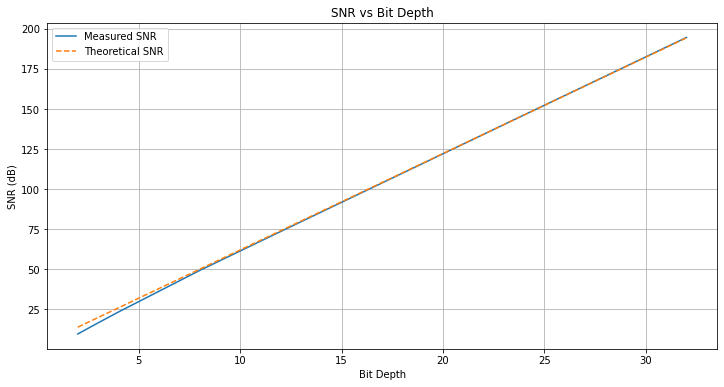


SNR at different bit depths:
Bits | Practical SNR | Theoretical SNR | Difference
--------------------------------------------------
   2 |         9.56 |          13.80 |       4.25
   3 |        16.47 |          19.82 |       3.35
   4 |        23.24 |          25.84 |       2.60
   8 |        49.14 |          49.93 |       0.78
  12 |        73.53 |          74.01 |       0.48
  24 |       146.31 |         146.26 |       0.06
  32 |       194.64 |         194.42 |       0.22


In [166]:
# Calculate SNR for different bit depths
bit_depths = [2,3,4,8,12,24,32]
practical_snr = []
theory_snr = []

for bits in bit_depths:
    # Practical SNR
    quantized = quantize_signal(sineWave, bits)
    snr = calculate_snr(sineWave, quantized)
    practical_snr.append(snr)
    
    # Theoretical SNR
    snr_theory = theoretical_snr(bits)
    theory_snr.append(snr_theory)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(bit_depths, practical_snr, label='Measured SNR')
plt.plot(bit_depths, theory_snr, '--', label='Theoretical SNR')
plt.grid(True)
plt.xlabel('Bit Depth')
plt.ylabel('SNR (dB)')
plt.title('SNR vs Bit Depth')
plt.legend()

plt.show()

# Print some example values
print("\nSNR at different bit depths:")
print("Bits | Practical SNR | Theoretical SNR | Difference")
print("-" * 50)
for bits, p_snr, t_snr in zip(bit_depths, practical_snr, theory_snr):
    print(f"{bits:4d} | {p_snr:12.2f} | {t_snr:14.2f} | {abs(p_snr-t_snr):10.2f}")